# Sprint 3 — Modelo Preditivo
### modelo-risco-sinistralidade-b2b

Objetivo: prever `teve_sinistro` (classificação binária) a partir das features
geradas no Sprint 2 (`data/dataset_features.csv`).

Modelos comparados:
- **Regressão Logística** (baseline interpretável)
- **Random Forest** (captura não-linearidades)

Métricas: AUC-ROC, precision, recall, f1, matriz de confusão.


## 1. Setup e carga do dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/dataset_features.csv")
print(df.shape)
df.head()


(10060, 54)


,empresa_id,razao_social,tempo_mercado_anos,faturamento_anual,num_funcionarios,apolice_id,valor_segurado,premio_anual,franquia,data_inicio,data_fim,teve_sinistro,qtd_sinistros_historico,razao_premio_valor_segurado,setor_comercio_varejo,setor_construcao_civil,setor_educacao,setor_industria,setor_saude,setor_servicos_financeiros,setor_servicos_profissionais,setor_tecnologia,setor_transporte_logistica,porte_grande,porte_media,porte_micro,porte_pequena,estado_BA,estado_CE,estado_DF,estado_GO,estado_MA,estado_MG,estado_PA,estado_PE,estado_PR,estado_RJ,estado_RS,estado_SC,estado_SP,cobertura_frota,cobertura_patrimonial,cobertura_responsabilidade_civil,cobertura_riscos_operacionais,faixa_tempo_mercado_3-5,faixa_tempo_mercado_6-10,faixa_tempo_mercado_11-20,faixa_tempo_mercado_20+,faixa_faturamento_Q2,faixa_faturamento_Q3,faixa_faturamento_Q4 (maior),faixa_funcionarios_Q2,faixa_funcionarios_Q3,faixa_funcionarios_Q4 (maior)
0,EMP000079,Ferreira e Filhos,3.9,132520.45,1,APL0000156,10492.77,140.33,222.56,2022-11-14,2023-11-14,False,0,0.013374,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False
1,EMP000005,Martins,11.9,192758.31,1,APL0000010,33714.13,685.23,1286.20,2025-10-23,2026-10-23,True,1,0.020325,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,False,False,False,False
2,EMP001113,Cassiano,0.8,4208266.21,25,APL0002216,1123498.08,13614.76,15353.00,2024-12-07,2025-12-07,True,3,0.012118,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False
3,EMP001482,Farias - EI,5.4,1290982.67,8,APL0002903,166290.15,3367.77,5768.83,2022-09-03,2023-09-03,False,0,0.020252,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False
4,EMP001914,Rios,8.5,175820.68,1,APL0003813,53878.11,599.86,2320.64,2024-07-17,2025-07-17,False,1,0.011134,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False


## 2. Preparação — X, y e colunas a excluir

In [2]:
# Colunas que não devem entrar no modelo (identificadores, texto livre, datas cruas)
cols_excluir = [
    "empresa_id", "razao_social", "apolice_id",
    "data_inicio", "data_fim", "teve_sinistro"
]

target = "teve_sinistro"

X = df.drop(columns=[c for c in cols_excluir if c in df.columns])
y = df[target].astype(int)

# Garante que só restaram colunas numéricas (as categóricas já foram one-hot no Sprint 2)
X = X.select_dtypes(include=[np.number])

print(f"Features: {X.shape[1]}")
print(f"Distribuição do target:\n{y.value_counts(normalize=True)}")


Features: 8
Distribuição do target:
teve_sinistro
0    0.826143
1    0.173857
Name: proportion, dtype: float64


## 3. Split treino/teste

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")
print(f"Taxa de sinistro treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}")


Treino: (8048, 8), Teste: (2012, 8)
Taxa de sinistro treino: 0.174 | teste: 0.174


## 4. Tratamento de desbalanceamento (SMOTE)

Aplicado **apenas no treino** — o teste permanece com a distribuição real,
para uma avaliação honesta do modelo.


In [4]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Antes do SMOTE: {y_train.value_counts().to_dict()}")
print(f"Depois do SMOTE: {y_train_res.value_counts().to_dict()}")


Antes do SMOTE: {0: 6649, 1: 1399}
Depois do SMOTE: {0: 6649, 1: 6649}


/Users/lfernandes/Documents/PROJETOS/insurance-risk-model/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## 5. Modelo 1 — Regressão Logística (baseline)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_res)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_lr):.3f}")


              precision    recall  f1-score   support

           0       1.00      0.80      0.89      1662
           1       0.52      1.00      0.68       350

    accuracy                           0.84      2012
   macro avg       0.76      0.90      0.79      2012
weighted avg       0.92      0.84      0.85      2012

AUC-ROC: 0.917


## 6. Modelo 2 — Random Forest

In [6]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_rf):.3f}")


              precision    recall  f1-score   support

           0       1.00      0.80      0.89      1662
           1       0.52      1.00      0.68       350

    accuracy                           0.84      2012
   macro avg       0.76      0.90      0.79      2012
weighted avg       0.92      0.84      0.85      2012

AUC-ROC: 0.894


## 7. Comparação — curva ROC

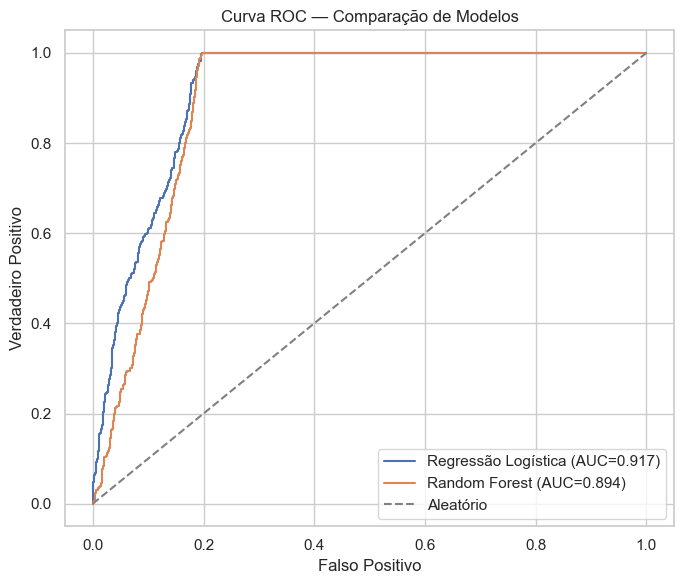

In [7]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Regressão Logística (AUC={roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
plt.xlabel("Falso Positivo")
plt.ylabel("Verdadeiro Positivo")
plt.title("Curva ROC — Comparação de Modelos")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Matriz de confusão (melhor modelo)

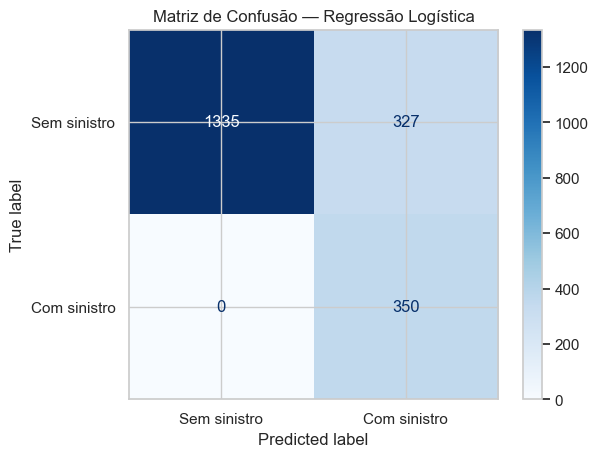

In [8]:
# Regressão Logística venceu no AUC-ROC (0.917 vs 0.894) — modelo final escolhido
melhor_pred = y_pred_lr

cm = confusion_matrix(y_test, melhor_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sem sinistro", "Com sinistro"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão — Regressão Logística")
plt.show()


## 9. Coeficientes do modelo (Regressão Logística)

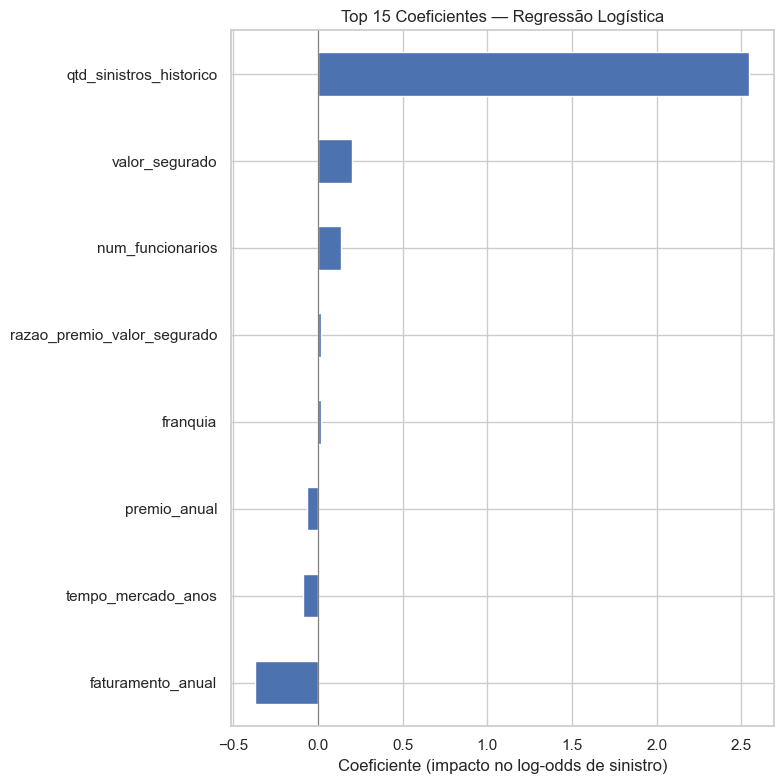

qtd_sinistros_historico        2.546616
faturamento_anual             -0.370344
valor_segurado                 0.202171
num_funcionarios               0.137793
tempo_mercado_anos            -0.091774
premio_anual                  -0.065161
razao_premio_valor_segurado    0.018960
franquia                       0.017567
dtype: float64

In [9]:
coeficientes = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 8))
coeficientes.head(15).sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 15 Coeficientes — Regressão Logística")
plt.xlabel("Coeficiente (impacto no log-odds de sinistro)")
plt.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

coeficientes.head(15)


## 10. Curva Precision-Recall (útil dado o desbalanceamento)

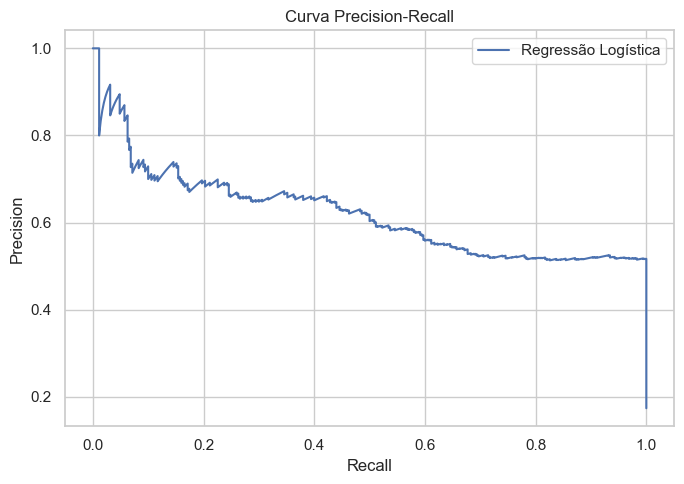

In [10]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_lr)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label="Regressão Logística")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Salvar o modelo final

Serializa o modelo escolhido + scaler + lista de features, para uso
posterior no dashboard (Sprint 4) ou em um script de scoring.


In [11]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(log_reg, "../models/modelo_sinistralidade_logreg.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(list(X.columns), "../models/features_modelo.pkl")

print("Modelo final (Regressão Logística) salvo em models/modelo_sinistralidade_logreg.pkl")
print("Scaler salvo em models/scaler.pkl")


Modelo final (Regressão Logística) salvo em models/modelo_sinistralidade_logreg.pkl
Scaler salvo em models/scaler.pkl


## 12. Principais resultados

- AUC-ROC — Regressão Logística: **0.917**
- AUC-ROC — Random Forest: 0.894
- **Modelo escolhido: Regressão Logística** (melhor AUC + mais interpretável, adequado a um caso sintético com relações majoritariamente lineares)
- Top features mais importantes: _preencher com base nos coeficientes da célula acima_
- Trade-off precision/recall observado: _...
